## Import necessary library


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import os
from matplotlib.colorbar import ColorbarBase

## Get File path and load the csv data


In [15]:
from util.data_path import cassava_price_avg_year_fix
from util.data_path import corn_price_avg_year_fix
from util.data_path import green_bean_price_avg_year_fix
from util.data_path import soybean_price_avg_year_fix

In [16]:
def process_csv(data_file):
    wide = pd.read_csv(data_file)
    long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
        ["year", "month"]
    )

    long["date"] = pd.to_datetime(
        (long["year"]).astype(str)
        + "-"
        + long["month"].astype(str).str.zfill(2)
        + "-01"
    )
    long = long.set_index("date").sort_index()
    return long


# Process each crop data
cassava_df = process_csv(cassava_price_avg_year_fix)
corn_df = process_csv(corn_price_avg_year_fix)
green_bean_df = process_csv(green_bean_price_avg_year_fix)
soybean_df = process_csv(soybean_price_avg_year_fix)

# Add crop name column to each dataframe
cassava_df["crop"] = "cassava"
corn_df["crop"] = "corn"
green_bean_df["crop"] = "green_bean"
soybean_df["crop"] = "soybean"

# Create a combined dataframe for all crops
all_crops_df = pd.concat([cassava_df, corn_df, green_bean_df, soybean_df])

In [17]:
normalized_df = all_crops_df.copy()

yearly_avg = all_crops_df.groupby(["crop", "year"])["price"].mean().reset_index()
yearly_avg.rename(columns={"price": "yearly_avg_price"}, inplace=True)

normalized_df = pd.merge(normalized_df, yearly_avg, on=["crop", "year"])
normalized_df["normalized_price"] = (
    normalized_df["price"] / normalized_df["yearly_avg_price"]
)

# Create a more structured result dataframe
result_df = normalized_df[
    ["year", "month", "crop", "price", "yearly_avg_price", "normalized_price"]
]
result_df = result_df.sort_values(["crop", "year", "month"])

In [18]:
# Debug: Check the structure and content of result_df
print("result_df shape:", result_df.shape)
print("result_df columns:", result_df.columns.tolist())
print("\nFirst few rows of result_df:")
print(result_df.head())
print(
    "\nUnique crops:",
    result_df["crop"].unique() if "crop" in result_df.columns else "No crop column",
)
print(
    "Year range:",
    result_df["year"].min() if "year" in result_df.columns else "No year column",
    "to",
    result_df["year"].max() if "year" in result_df.columns else "",
)

result_df shape: (1008, 6)
result_df columns: ['year', 'month', 'crop', 'price', 'yearly_avg_price', 'normalized_price']

First few rows of result_df:
    year month     crop  price  yearly_avg_price  normalized_price
0   2004     1  cassava   0.99              1.12          0.883929
9   2004    10  cassava   1.11              1.12          0.991071
10  2004    11  cassava   1.19              1.12          1.062500
11  2004    12  cassava   1.30              1.12          1.160714
1   2004     2  cassava   0.95              1.12          0.848214

Unique crops: ['cassava' 'corn' 'green_bean' 'soybean']
Year range: 2004 to 2024


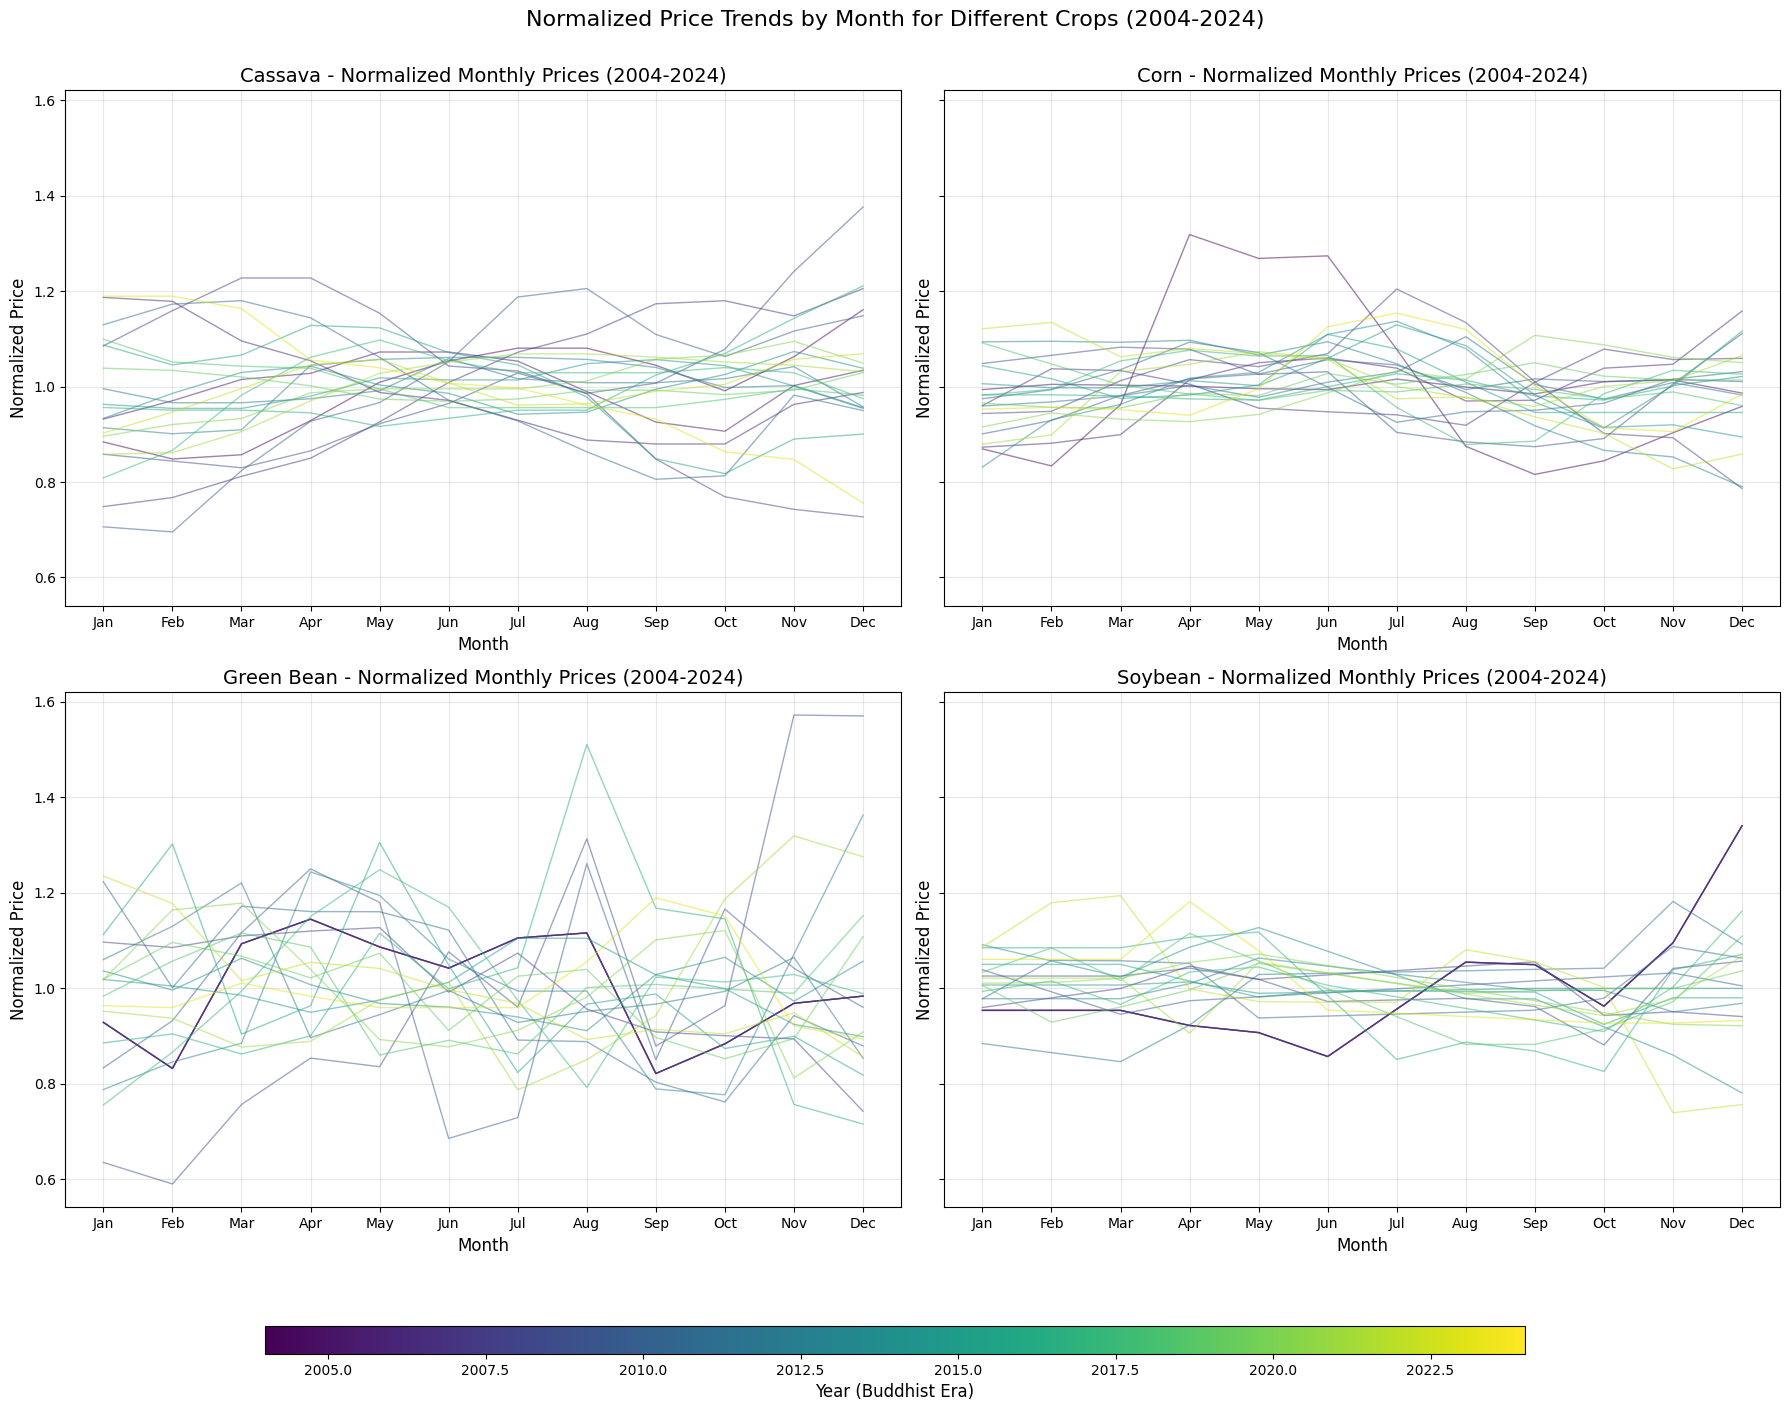

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()

# Define a colormap for the years
years = sorted(result_df["year"].unique())
colormap = plt.cm.viridis
colors = {year: colormap(i / len(years)) for i, year in enumerate(years)}

# Create a list of crops
crops = ["cassava", "corn", "green_bean", "soybean"]
titles = ["Cassava", "Corn", "Green Bean", "Soybean"]

# Plot each crop on its own subplot
for i, (crop, title) in enumerate(zip(crops, titles)):
    crop_data = result_df[result_df["crop"] == crop]

    # Plot each year's data
    for year in years:
        year_data = crop_data[crop_data["year"] == year]
        year_data = year_data.copy()

        year_data["month_num"] = pd.to_numeric(year_data["month"])
        year_data = year_data.sort_values("month_num")

        axes[i].plot(
            year_data["month_num"],
            year_data["normalized_price"],
            color=colors[year],
            alpha=0.5,
            linewidth=1,
        )

    axes[i].set_title(f"{title} - Normalized Monthly Prices (2004-2024)", fontsize=14)
    axes[i].set_xlabel("Month", fontsize=12)
    axes[i].set_ylabel("Normalized Price", fontsize=12)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
    axes[i].grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(min(years), max(years)))
sm.set_array([])

# Adjust layout first to properly position the plots
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# Add colorbar at the bottom with more padding and lower position
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Year (Buddhist Era)", fontsize=12)

# Add the title with adjusted y position
plt.suptitle(
    "Normalized Price Trends by Month for Different Crops (2004-2024)",
    fontsize=16,
    y=0.98,
)

plt.show()

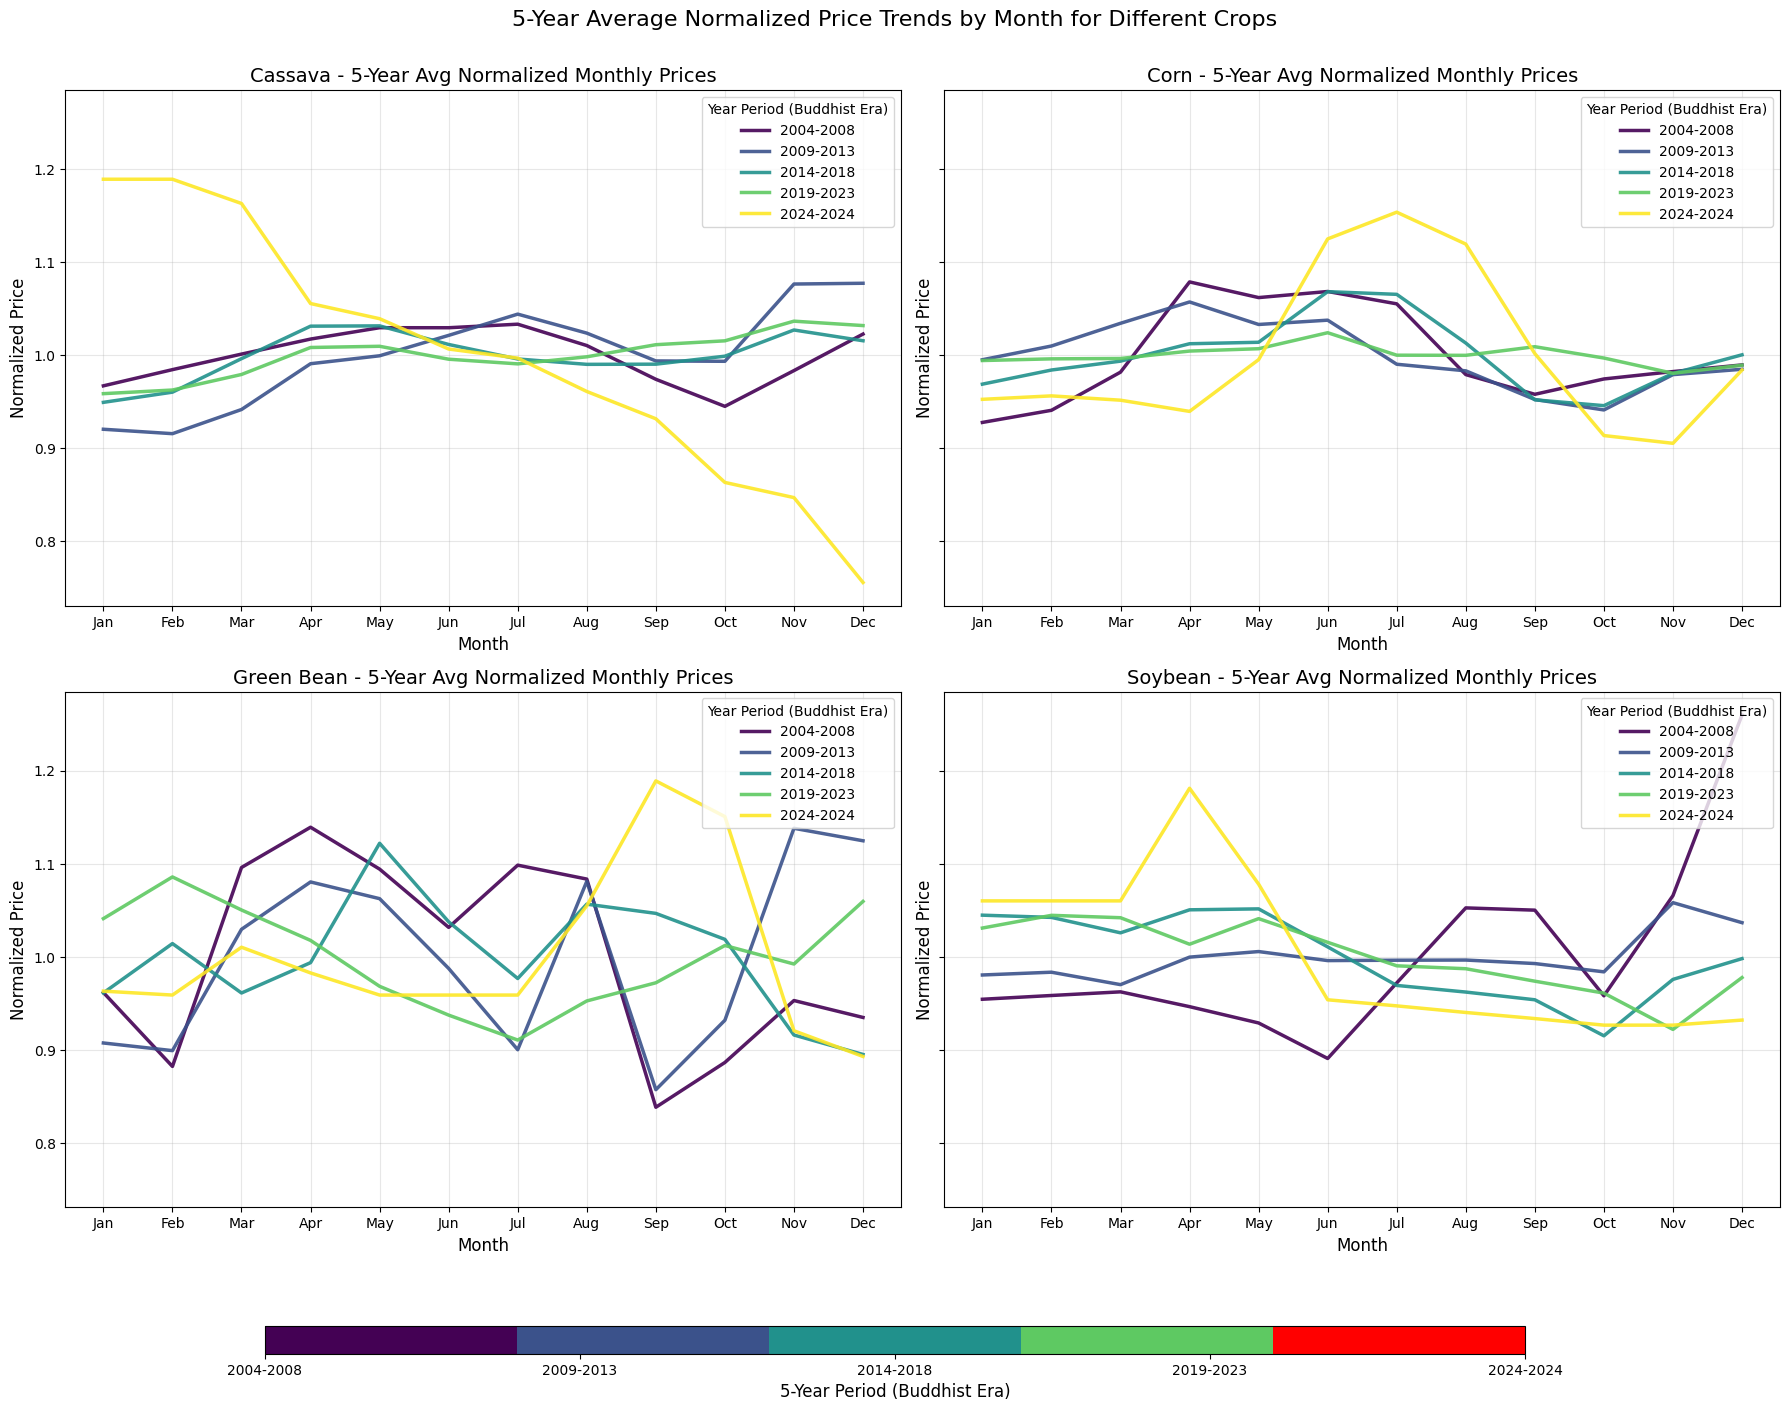

In [20]:
# Define 5-year periods
# Get the min and max years from the data
min_year = result_df["year"].min()
max_year = result_df["year"].max()

# Create period ranges that cover all available years
periods = []
current_year = min_year
while current_year <= max_year:
    end_year = min(current_year + 4, max_year)
    periods.append((current_year, end_year))
    current_year = end_year + 1

# Create a period label for each year
result_df["period"] = result_df["year"].apply(
    lambda y: next((f"{p[0]}-{p[1]}" for p in periods if p[0] <= y <= p[1]), "Unknown")
)

# Calculate the average normalized price by month for each crop and period
period_avg = (
    result_df.groupby(["crop", "period", "month"])["normalized_price"]
    .mean()
    .reset_index()
)

# Sort the periods chronologically
period_avg["period_start"] = period_avg["period"].apply(lambda p: int(p.split("-")[0]))
period_avg = period_avg.sort_values(["crop", "period_start", "month"])

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()

# Define a colormap for the periods
unique_periods = sorted(
    period_avg["period"].unique(), key=lambda p: int(p.split("-")[0])
)
colormap = plt.cm.viridis

# Create custom colors dictionary - using red for the period containing year 2567
colors = {}
for i, period in enumerate(unique_periods):
    # Check if this period contains year 2567
    if "2567" in period:
        colors[period] = "red"  # Set to red
    else:
        colors[period] = colormap(
            i / (len(unique_periods) - 1)
        )  # Use colormap for others

# Create a list of crops
crops = ["cassava", "corn", "green_bean", "soybean"]
titles = ["Cassava", "Corn", "Green Bean", "Soybean"]

# Plot each crop on its own subplot
for i, (crop, title) in enumerate(zip(crops, titles)):
    crop_data = period_avg[period_avg["crop"] == crop]

    # Plot each period's average data
    for period in unique_periods:
        period_data = crop_data[crop_data["period"] == period]
        period_data = period_data.copy()

        period_data["month_num"] = pd.to_numeric(period_data["month"])
        period_data = period_data.sort_values("month_num")

        # Use thicker line for the period with 2567
        line_width = 3.5 if "2567" in period else 2.5

        axes[i].plot(
            period_data["month_num"],
            period_data["normalized_price"],
            color=colors[period],
            alpha=0.9,
            linewidth=line_width,
            label=period,
        )

    # Add labels and formatting
    axes[i].set_title(f"{title} - 5-Year Avg Normalized Monthly Prices", fontsize=14)
    axes[i].set_xlabel("Month", fontsize=12)
    axes[i].set_ylabel("Normalized Price", fontsize=12)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(title="Year Period (Buddhist Era)", loc="upper right")

# Create a special colormap for the colorbar that includes red for 2567


# Create colors array for the colorbar
num_periods = len(unique_periods)
color_array = np.zeros((num_periods, 4))  # RGBA

# Fill with colormap colors
for i in range(num_periods - 1):
    color_array[i] = colormap(i / (num_periods - 1))

# Set the last period (2567) to red
color_array[-1] = np.array([1, 0, 0, 1])  # Red in RGBA

custom_cmap = ListedColormap(color_array)

# Create colorbar
sm = plt.cm.ScalarMappable(
    cmap=custom_cmap, norm=plt.Normalize(0, len(unique_periods) - 1)
)
sm.set_array([])

# Adjust layout first to properly position the plots
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# Add colorbar at the bottom with more padding and lower position
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
ticks = range(len(unique_periods))
tick_labels = unique_periods
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels)
cbar.set_label("5-Year Period (Buddhist Era)", fontsize=12)

# Add the title with adjusted y position
plt.suptitle(
    "5-Year Average Normalized Price Trends by Month for Different Crops",
    fontsize=16,
    y=0.98,
)

plt.show()

Data year range: 2004 to 2024
Created 17 periods: [(2004, 2008), (2005, 2009), (2006, 2010), (2007, 2011), (2008, 2012), (2009, 2013), (2010, 2014), (2011, 2015), (2012, 2016), (2013, 2017), (2014, 2018), (2015, 2019), (2016, 2020), (2017, 2021), (2018, 2022), (2019, 2023), (2020, 2024)]
Columns in shifted_period_df: ['year', 'month', 'crop', 'price', 'yearly_avg_price', 'normalized_price', 'period']
Number of rows in shifted_period_df: 4080
Sample periods: ['2004-2008' '2005-2009' '2006-2010' '2007-2011' '2008-2012']
Columns in shifted_period_df: ['year', 'month', 'crop', 'price', 'yearly_avg_price', 'normalized_price', 'period']
Number of rows in shifted_period_df: 4080
Sample periods: ['2004-2008' '2005-2009' '2006-2010' '2007-2011' '2008-2012']


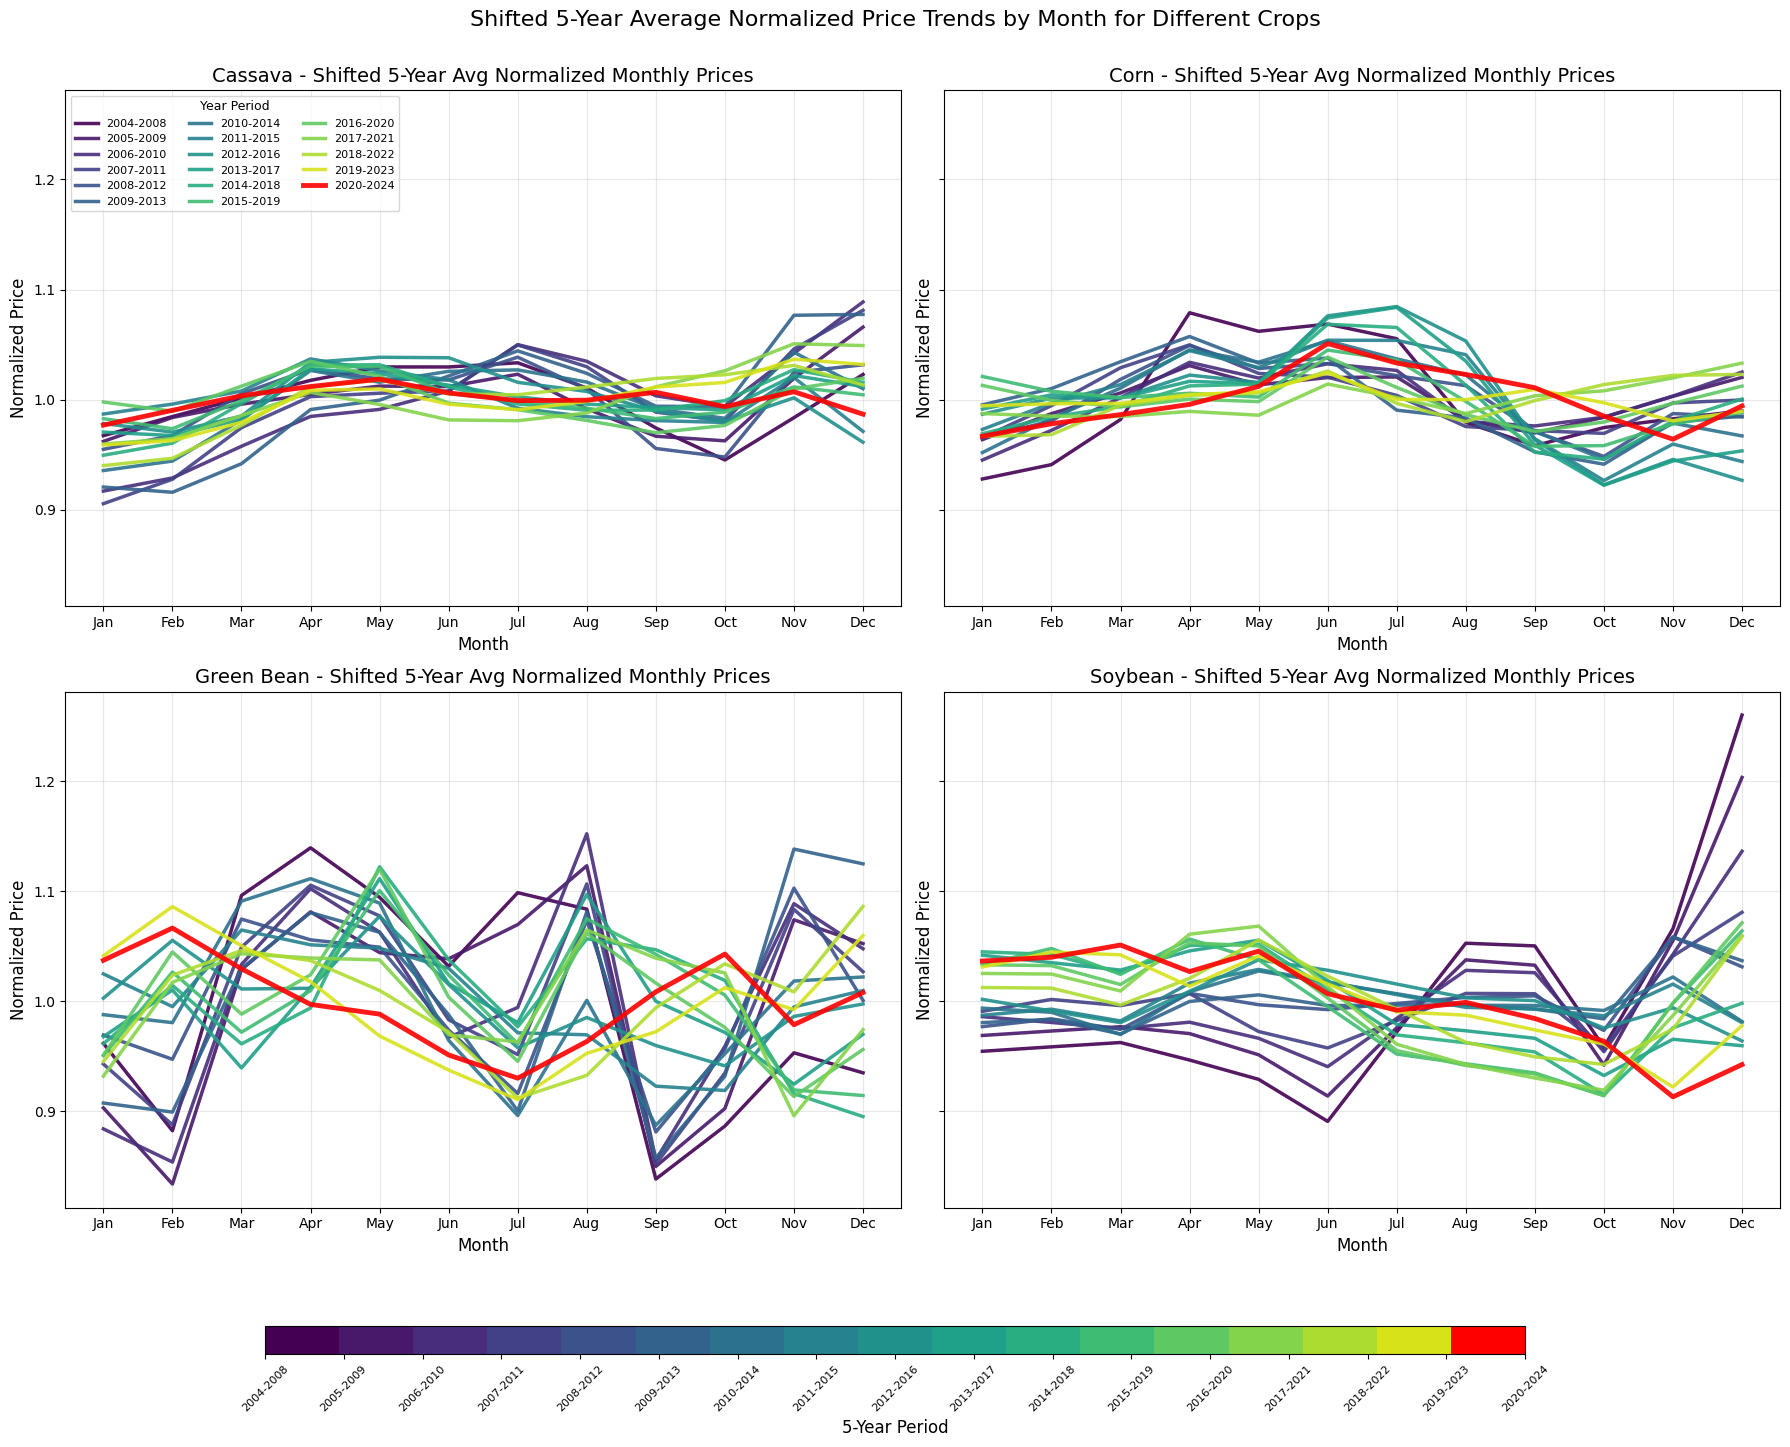

In [21]:
# Create 5-year periods with a 1-year shift
min_year = result_df["year"].min()
max_year = result_df["year"].max()

print(f"Data year range: {min_year} to {max_year}")

# Define the specific periods that overlap with the available data
# Using the actual data range (2004-2024) instead of 2547-2564
periods = []
for start_year in range(
    min_year, max_year - 3
):  # Ensure we have at least 4 years for a 5-year period
    end_year = start_year + 4
    if end_year <= max_year:
        periods.append((start_year, end_year))

print(f"Created {len(periods)} periods: {periods}")


# Create a function to assign each year to all applicable periods
def assign_periods(year):
    applicable_periods = []
    for start, end in periods:
        if start <= year <= end:
            applicable_periods.append(f"{start}-{end}")
    return applicable_periods


# Create an expanded dataframe with rows duplicated for each applicable period
expanded_rows = []
for _, row in result_df.iterrows():
    year = row["year"]
    applicable_periods = assign_periods(year)
    for period in applicable_periods:
        new_row = row.copy()
        new_row["period"] = period
        expanded_rows.append(new_row)

# Convert to DataFrame properly preserving all columns
shifted_period_df = pd.DataFrame(expanded_rows)

# Verify that all required columns exist
print("Columns in shifted_period_df:", shifted_period_df.columns.tolist())
print("Number of rows in shifted_period_df:", len(shifted_period_df))
print(
    "Sample periods:",
    shifted_period_df["period"].unique()[:5]
    if len(shifted_period_df) > 0
    else "No data",
)

# Only proceed if we have data
if len(shifted_period_df) > 0:
    # Calculate the average normalized price by month for each crop and period
    period_avg = (
        shifted_period_df.groupby(["crop", "period", "month"])["normalized_price"]
        .mean()
        .reset_index()
    )

    # Sort the periods chronologically
    period_avg["period_start"] = period_avg["period"].apply(
        lambda p: int(p.split("-")[0])
    )
    period_avg = period_avg.sort_values(["crop", "period_start", "month"])

    # Plot the results
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
    axes = axes.flatten()

    # Define a colormap for the periods
    unique_periods = sorted(
        period_avg["period"].unique(), key=lambda p: int(p.split("-")[0])
    )
    colormap = plt.cm.viridis

    # Create custom colors dictionary - using red for the latest period
    colors = {}
    for i, period in enumerate(unique_periods):
        # Check if this is the latest period (contains the most recent years)
        period_end = int(period.split("-")[1])
        if period_end == max_year:
            colors[period] = "red"  # Set to red for the most recent period
        else:
            colors[period] = colormap(
                i / (len(unique_periods) - 1)
            )  # Use colormap for others

    # Create a list of crops
    crops = ["cassava", "corn", "green_bean", "soybean"]
    titles = ["Cassava", "Corn", "Green Bean", "Soybean"]

    # Plot each crop on its own subplot
    for i, (crop, title) in enumerate(zip(crops, titles)):
        crop_data = period_avg[period_avg["crop"] == crop]

        # Plot each period's average data
        for period in unique_periods:
            period_data = crop_data[crop_data["period"] == period]
            period_data = period_data.copy()

            period_data["month_num"] = pd.to_numeric(period_data["month"])
            period_data = period_data.sort_values("month_num")

            # Use thicker line for the latest period
            line_width = 3.5 if int(period.split("-")[1]) == max_year else 2.5

            axes[i].plot(
                period_data["month_num"],
                period_data["normalized_price"],
                color=colors[period],
                alpha=0.9,
                linewidth=line_width,
                label=period,
            )

        # Add labels and formatting
        axes[i].set_title(
            f"{title} - Shifted 5-Year Avg Normalized Monthly Prices", fontsize=14
        )
        axes[i].set_xlabel("Month", fontsize=12)
        axes[i].set_ylabel("Normalized Price", fontsize=12)
        axes[i].set_xticks(range(1, 13))
        axes[i].set_xticklabels(
            [
                "Jan",
                "Feb",
                "Mar",
                "Apr",
                "May",
                "Jun",
                "Jul",
                "Aug",
                "Sep",
                "Oct",
                "Nov",
                "Dec",
            ]
        )
        axes[i].grid(True, alpha=0.3)

        # Use a more compact legend with smaller font
        if i == 0:  # Only add the legend to the first subplot
            axes[i].legend(
                title="Year Period",
                loc="upper left",
                fontsize=8,
                title_fontsize=9,
                bbox_to_anchor=(0, 1),
                ncol=3,
            )

    # Create colors array for the colorbar
    num_periods = len(unique_periods)
    color_array = np.zeros((num_periods, 4))  # RGBA

    # Fill with colormap colors
    for i, period in enumerate(unique_periods):
        if int(period.split("-")[1]) == max_year:
            color_array[i] = np.array([1, 0, 0, 1])  # Red for latest period
        else:
            color_array[i] = colormap(i / (num_periods - 1))

    custom_cmap = ListedColormap(color_array)

    # Create colorbar
    sm = plt.cm.ScalarMappable(
        cmap=custom_cmap, norm=plt.Normalize(0, len(unique_periods) - 1)
    )
    sm.set_array([])

    # Adjust layout first to properly position the plots
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    # Add colorbar at the bottom with more padding and lower position
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    ticks = range(len(unique_periods))
    tick_labels = unique_periods
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels, rotation=45, fontsize=8)
    cbar.set_label("5-Year Period", fontsize=12)

    # Add the title with adjusted y position
    plt.suptitle(
        "Shifted 5-Year Average Normalized Price Trends by Month for Different Crops",
        fontsize=16,
        y=0.98,
    )

    plt.show()
else:
    print("No data available for the specified periods. Please check the year ranges.")

In [22]:
output_dir = "../model/image/transitions"
os.makedirs(output_dir, exist_ok=True)

# Create a better colormap with more distinct colors for visualization
colormap = plt.cm.plasma

# Create colors dictionary for all periods - ensure proper sorting
unique_periods_sorted = sorted(unique_periods, key=lambda p: int(p.split("-")[0]))
num_periods = len(unique_periods_sorted)

# Create a consistent color scheme across all visualizations
# First create a continuous colormap for all non-2567 periods
colors = {}
for i, period in enumerate(unique_periods_sorted):
    if "2567" in period:
        # Make the 2567 period stand out with pure red
        colors[period] = (1.0, 0.0, 0.0, 1.0)  # Pure red
    else:
        # Adjust the index to account for one spot reserved for red
        colors[period] = colormap(i / (num_periods - 1))

# Create a custom colormap that includes all colors in the exact order
color_array = np.zeros((num_periods, 4))  # RGBA array
for i, period in enumerate(unique_periods_sorted):
    color_array[i] = colors[period]

# Create a ListedColormap from this array for consistent display
custom_cmap = ListedColormap(color_array)

# Create GIF animations for each crop separately
for crop_idx, (crop, title) in enumerate(zip(crops, titles)):
    crop_data = period_avg[period_avg["crop"] == crop]

    # Create a figure for this crop
    fig = plt.figure(figsize=(12, 8))

    # Create a main axis for the plot and a small axis for the colorbar
    ax = plt.subplot2grid((10, 10), (0, 0), colspan=10, rowspan=8)
    cax = plt.subplot2grid((10, 10), (9, 1), colspan=8, rowspan=1)

    # Get the y-axis limits from all data for this crop to keep it consistent
    min_y = crop_data["normalized_price"].min() * 0.95  # Add some padding
    max_y = crop_data["normalized_price"].max() * 1.05

    # Create a colorbar with all periods using the custom colormap
    norm = plt.Normalize(0, num_periods - 1)
    cb = ColorbarBase(
        cax,
        cmap=custom_cmap,
        norm=norm,
        orientation="horizontal",
        label="5-Year Period (Buddhist Era)",
    )

    # Set colorbar ticks and labels
    cb.set_ticks(np.arange(num_periods))
    cb.set_ticklabels(unique_periods_sorted)
    for label in cb.ax.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(8)

    # Create a class to store state between animation frames
    class AnimState:
        def __init__(self):
            self.prev_period_data = None

    anim_state = AnimState()

    # Function to update the plot for each frame (period)
    def update(frame_idx):
        ax.clear()
        period = unique_periods_sorted[frame_idx]
        period_data = crop_data[crop_data["period"] == period]
        period_data = period_data.copy()
        period_data["month_num"] = pd.to_numeric(period_data["month"])
        period_data = period_data.sort_values("month_num")

        # Use the color from our colormap
        line_color = colors[period]
        line_width = 3

        # If we have previous period data, plot it as a dotted line
        if frame_idx > 0 and anim_state.prev_period_data is not None:
            prev_period = unique_periods_sorted[frame_idx - 1]
            ax.plot(
                anim_state.prev_period_data["month_num"],
                anim_state.prev_period_data["normalized_price"],
                color=colors[prev_period],
                linewidth=2,
                linestyle="--",
                alpha=0.6,
                label=f"Previous: {prev_period}",
            )

        # Plot the current line
        line = ax.plot(
            period_data["month_num"],
            period_data["normalized_price"],
            color=line_color,
            linewidth=line_width,
            label=f"Current: {period}",
        )[0]

        # Store current line and data for the next frame
        anim_state.prev_period_data = period_data

        # Add labels and formatting
        ax.set_title(f"{title} - 5-Year Period: {period} (Buddhist Era)", fontsize=14)
        ax.set_xlabel("Month", fontsize=12)
        ax.set_ylabel("Normalized Price", fontsize=12)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(
            [
                "Jan",
                "Feb",
                "Mar",
                "Apr",
                "May",
                "Jun",
                "Jul",
                "Aug",
                "Sep",
                "Oct",
                "Nov",
                "Dec",
            ]
        )
        ax.set_ylim(min_y, max_y)  # Keep y-axis consistent
        ax.grid(True, alpha=0.3)

        # Add legend except for the first frame
        if frame_idx > 0:
            ax.legend(loc="upper right", fontsize=10)

        # Add text showing the frame number / total frames
        ax.text(
            0.02,
            0.02,
            f"Period {frame_idx + 1}/{num_periods}",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

        # Highlight the current period in the colorbar
        # Create a rectangle patch to highlight the current position in colorbar
        # Calculate exact position for proper alignment with ticks
        rect_x = frame_idx / num_periods
        rect_width = 1 / num_periods
        rect = plt.Rectangle(
            (rect_x, 0),
            rect_width,
            1,
            transform=cax.transAxes,
            edgecolor="white",
            facecolor="none",
            linewidth=2,
            zorder=5,
        )
        cax.add_patch(rect)

        return [line, rect]

    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=num_periods, blit=False)

    # Save as GIF with higher quality
    writer = PillowWriter(fps=1)  # 1 frame per second for better visibility
    gif_path = os.path.join(output_dir, f"{crop}_transition.gif")
    ani.save(gif_path, writer=writer)

    plt.close(fig)
    print(f"GIF for {title} saved to: {gif_path}")

# Create a combined visualization showing all transitions simultaneously
fig = plt.figure(figsize=(14, 12))

# Create a grid for the plots and colorbar
gs = fig.add_gridspec(11, 10)
axes = [
    fig.add_subplot(gs[0:5, 0:5]),
    fig.add_subplot(gs[0:5, 5:10]),
    fig.add_subplot(gs[5:10, 0:5]),
    fig.add_subplot(gs[5:10, 5:10]),
]
cax = fig.add_subplot(gs[10, 1:9])

# Find global min/max for consistent y-axis
min_y = period_avg["normalized_price"].min() * 0.95
max_y = period_avg["normalized_price"].max() * 1.05

# Initialize lines for each crop subplot - for both current and previous
current_lines = []
previous_lines = []
for i, (crop, title) in enumerate(zip(crops, titles)):
    # Initialize an empty line for current period
    (current_line,) = axes[i].plot([], [], linewidth=3)
    current_lines.append(current_line)

    # Initialize an empty line for previous period (dashed)
    (previous_line,) = axes[i].plot([], [], linewidth=2, linestyle="--", alpha=0.6)
    previous_lines.append(previous_line)

    # Set up axes
    axes[i].set_title(f"{title}", fontsize=14)
    axes[i].set_xlabel("Month", fontsize=12)
    axes[i].set_ylabel("Normalized Price", fontsize=12)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
    axes[i].set_ylim(min_y, max_y)
    axes[i].grid(True, alpha=0.3)

# Create a colorbar in the bottom subplot - use the same custom_cmap for consistency
cb = ColorbarBase(
    cax,
    cmap=custom_cmap,
    norm=norm,
    orientation="horizontal",
    label="5-Year Period (Buddhist Era)",
)

# Set colorbar ticks and labels
cb.set_ticks(np.arange(num_periods))
cb.set_ticklabels(unique_periods_sorted)
for label in cb.ax.get_xticklabels():
    label.set_rotation(45)
    label.set_fontsize(8)

# Text for showing current period
period_text = fig.text(0.5, 0.01, "", ha="center", fontsize=14)
rect = None  # Initialize rectangle reference

# Dictionary to store previous period data
prev_period_data = {}


# Update function for animation
def update_combined(frame_idx):
    global rect

    period = unique_periods_sorted[frame_idx]
    current_color = colors[period]

    # Initialize previous period info
    prev_period = None
    prev_color = None

    if frame_idx > 0:
        prev_period = unique_periods_sorted[frame_idx - 1]
        prev_color = colors[prev_period]

    # Update text
    period_text.set_text(f"5-Year Period: {period} (Buddhist Era)")

    # Update each crop plot
    for i, (crop, current_line, previous_line) in enumerate(
        zip(crops, current_lines, previous_lines)
    ):
        crop_data = period_avg[period_avg["crop"] == crop]

        # Get current period data
        current_period_data = crop_data[crop_data["period"] == period].copy()
        current_period_data["month_num"] = pd.to_numeric(current_period_data["month"])
        current_period_data = current_period_data.sort_values("month_num")

        # Update current line
        current_line.set_color(current_color)
        current_line.set_data(
            current_period_data["month_num"], current_period_data["normalized_price"]
        )

        # Store this data for next frame
        prev_period_data[crop] = current_period_data

        # If we have previous period data, show it as dotted line
        if frame_idx > 0 and prev_period is not None:
            previous_period_data = crop_data[crop_data["period"] == prev_period].copy()
            previous_period_data["month_num"] = pd.to_numeric(
                previous_period_data["month"]
            )
            previous_period_data = previous_period_data.sort_values("month_num")

            previous_line.set_color(prev_color)
            previous_line.set_data(
                previous_period_data["month_num"],
                previous_period_data["normalized_price"],
            )
        else:
            # No previous data for first frame
            previous_line.set_data([], [])

    # Remove previous rectangle if it exists
    if rect is not None:
        rect.remove()

    # Create a rectangle patch to highlight the current position in colorbar
    # Calculate exact position in colorbar for proper alignment with ticks
    rect_x = frame_idx / num_periods
    rect_width = 1 / num_periods
    rect = plt.Rectangle(
        (rect_x, 0),
        rect_width,
        1,
        transform=cax.transAxes,
        edgecolor="white",
        facecolor="none",
        linewidth=2,
        zorder=5,
    )
    cax.add_patch(rect)

    # Add legend to first subplot
    if frame_idx > 0:
        # Only add legend if there's a previous period
        handles = [
            plt.Line2D([0], [0], color=current_color, lw=3, label=f"Current: {period}"),
            plt.Line2D(
                [0],
                [0],
                color=prev_color,
                lw=2,
                linestyle="--",
                alpha=0.6,
                label=f"Previous: {prev_period}",
            ),
        ]
        axes[0].legend(handles=handles, loc="upper left", fontsize=9)
    else:
        # Clear any existing legend for first frame
        if axes[0].get_legend() is not None:
            axes[0].get_legend().remove()

    return current_lines + previous_lines + [period_text, rect]


# Create the combined animation
ani_combined = animation.FuncAnimation(
    fig, update_combined, frames=num_periods, blit=False
)

# Save the combined GIF with higher quality
writer = PillowWriter(fps=1)  # 1 frame per second
combined_gif_path = os.path.join(output_dir, "all_crops_transition.gif")
ani_combined.save(combined_gif_path, writer=writer)
plt.close(fig)

print(f"Combined GIF saved to: {combined_gif_path}")
print("All enhanced GIFs have been created successfully!")

GIF for Cassava saved to: ../model/image/transitions\cassava_transition.gif
GIF for Corn saved to: ../model/image/transitions\corn_transition.gif
GIF for Corn saved to: ../model/image/transitions\corn_transition.gif
GIF for Green Bean saved to: ../model/image/transitions\green_bean_transition.gif
GIF for Green Bean saved to: ../model/image/transitions\green_bean_transition.gif
GIF for Soybean saved to: ../model/image/transitions\soybean_transition.gif
GIF for Soybean saved to: ../model/image/transitions\soybean_transition.gif
Combined GIF saved to: ../model/image/transitions\all_crops_transition.gif
All enhanced GIFs have been created successfully!
Combined GIF saved to: ../model/image/transitions\all_crops_transition.gif
All enhanced GIFs have been created successfully!
